# Airbnb European Markets: Price Prediction Research Questions

This notebook answers RQ1–RQ7 using a consistent supervised learning pipeline.

**Target variable:** `booked_rate_avg`

Run cells from top to bottom. The notebook will automatically load `.parquet` files if available, otherwise `.csv` files from the same directory.

## 0. Install dependencies

In [ ]:
# Run this cell once if packages are missing.
# If pyarrow/fastparquet installation succeeds, restart the kernel before loading parquet files.

import sys
!{sys.executable} -m pip install -q pandas numpy matplotlib seaborn scikit-learn pyarrow fastparquet joblib

## 1. Imports and output folders

In [1]:
from pathlib import Path
import warnings
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split, cross_validate, KFold
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder, StandardScaler, RobustScaler
from sklearn.impute import SimpleImputer
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from sklearn.linear_model import LinearRegression, Ridge
from sklearn.dummy import DummyRegressor
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor
from sklearn.inspection import permutation_importance
from sklearn.base import clone
import joblib

try:
    from sklearn.svm import SVR
except Exception:
    SVR = None

BASE_DIR = Path('.')
OUTPUT_DIR = BASE_DIR / 'outputs'
FIGURE_DIR = OUTPUT_DIR / 'figures'
TABLE_DIR = OUTPUT_DIR / 'tables'
MODEL_DIR = OUTPUT_DIR / 'models'
for p in [OUTPUT_DIR, FIGURE_DIR, TABLE_DIR, MODEL_DIR]:
    p.mkdir(parents=True, exist_ok=True)

RANDOM_STATE = 42
TARGET_COLUMN = 'booked_rate_avg'

print('Working directory:', BASE_DIR.resolve())
print('Output directory:', OUTPUT_DIR.resolve())

Working directory: /Users/oleg/ML_homework
Output directory: /Users/oleg/ML_homework/outputs


## 2. Load raw data

The loader first looks for parquet files. If none are found, it loads CSV files. If CSV parsing fails, it retries with bad lines skipped.

In [2]:
def infer_city_and_period(filename: str):
    name = filename.lower().replace('.csv', '').replace('.parquet', '')
    parts = name.replace('-', '_').split('_')
    known_periods = ['weekdays', 'weekends', 'weekday', 'weekend', 'past', 'rates']
    city = parts[0] if parts else 'unknown'
    period = 'unknown'
    for p in known_periods:
        if p in parts or p in name:
            period = p
            break
    return city, period

def load_one_file(file_path: Path) -> pd.DataFrame:
    if file_path.suffix.lower() == '.parquet':
        df_temp = pd.read_parquet(file_path)
    elif file_path.suffix.lower() == '.csv':
        try:
            df_temp = pd.read_csv(file_path)
        except pd.errors.ParserError:
            print(f'ParserError in {file_path.name}; retrying with engine="python" and on_bad_lines="skip"')
            df_temp = pd.read_csv(file_path, engine='python', on_bad_lines='skip')
    else:
        raise ValueError(f'Unsupported file type: {file_path}')
    city, period = infer_city_and_period(file_path.name)
    df_temp['source_file'] = file_path.name
    if 'city' not in df_temp.columns:
        df_temp['city'] = city
    if 'period' not in df_temp.columns:
        df_temp['period'] = period
    return df_temp

parquet_files = sorted([p for p in BASE_DIR.glob('*.parquet') if not p.name.startswith('.')])
csv_files = sorted([p for p in BASE_DIR.glob('*.csv') if not p.name.startswith('.')])

print('Parquet files found:', [p.name for p in parquet_files])
print('CSV files found:', [p.name for p in csv_files])

files_to_load = parquet_files if parquet_files else csv_files
if not files_to_load:
    raise FileNotFoundError('No .parquet or .csv files found in the current directory.')

raw_tables = []
for fp in files_to_load:
    print('Loading:', fp.name)
    raw_tables.append(load_one_file(fp))

raw_data = pd.concat(raw_tables, ignore_index=True, sort=False)
print('Raw data shape:', raw_data.shape)
display(raw_data.head())

(pd.DataFrame({'column': raw_data.columns, 'dtype': [str(raw_data[c].dtype) for c in raw_data.columns], 'missing_rate': raw_data.isna().mean().values})
 .to_csv(TABLE_DIR / 'raw_columns_overview.csv', index=False))

Parquet files found: ['listings.parquet', 'past_rates.parquet']
CSV files found: []
Loading: listings.parquet
Loading: past_rates.parquet
Raw data shape: (1211072, 76)


,listing_id,listing_type,room_type,cover_photo_url,photos_count,host_id,superhost,latitude,longitude,guests,...,occupancy,revenue,rate_avg,booked_rate_avg,booking_lead_time_avg,length_of_stay_avg,min_nights_avg,native_booked_rate_avg,native_rate_avg,native_revenue
0,121902,Entire home,entire_home,https://a0.muscache.com/im/pictures/77c0e3a9-0...,77,fe453949b595,false,37.0758,27.2426,6,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,805342,Entire condo,entire_home,https://a0.muscache.com/im/pictures/11494599/4...,16,59711ec4c245,false,37.0092,27.2563,3,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,805361,Entire home,entire_home,https://a0.muscache.com/im/pictures/bda48dbc-d...,34,d217bf6e3427,false,37.0292,27.4410,5,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,853827,Entire villa,entire_home,https://a0.muscache.com/im/pictures/26626113/a...,70,605fc7d80e02,false,37.0434,27.2517,16,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,967193,Entire villa,entire_home,https://a0.muscache.com/im/pictures/68107669/2...,37,3b963e8cd040,false,37.0429,27.3898,4,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


## 3. Target selection and basic target cleaning

Using target column: booked_rate_avg
Shape after target cleaning: (717806, 76)


count    717806.000000
mean        159.783847
std         168.400040
min           8.400000
25%          76.200000
50%         114.000000
75%         180.500000
max        4530.700000
Name: booked_rate_avg, dtype: float64

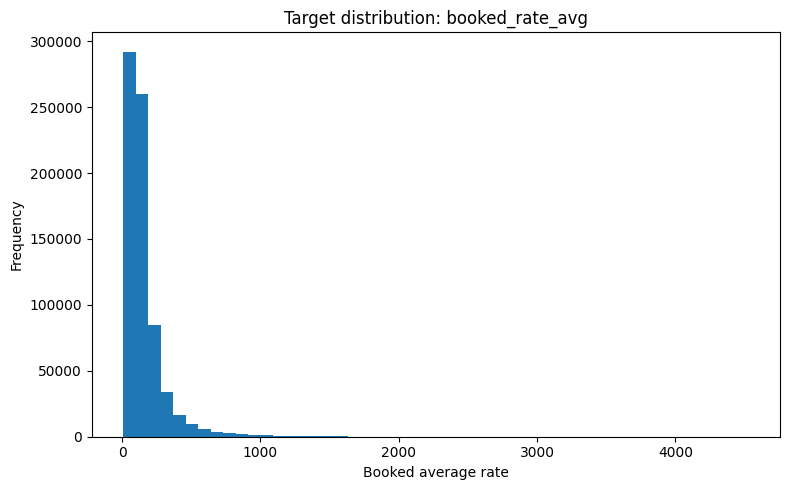

In [3]:
def clean_price_series(s: pd.Series) -> pd.Series:
    if pd.api.types.is_numeric_dtype(s):
        return pd.to_numeric(s, errors='coerce')
    return pd.to_numeric(
        s.astype(str).str.replace(r'[^0-9.\-]', '', regex=True).replace('', np.nan),
        errors='coerce'
    )

if TARGET_COLUMN not in raw_data.columns:
    price_like = [c for c in raw_data.columns if any(x in c.lower() for x in ['price', 'rate', 'sum'])]
    raise ValueError(f'TARGET_COLUMN={TARGET_COLUMN!r} not found. Price/rate-like columns: {price_like}')

df = raw_data.copy()
df[TARGET_COLUMN] = clean_price_series(df[TARGET_COLUMN])
df = df.dropna(subset=[TARGET_COLUMN])
df = df[df[TARGET_COLUMN] > 0].copy()

print('Using target column:', TARGET_COLUMN)
print('Shape after target cleaning:', df.shape)
display(df[TARGET_COLUMN].describe())

plt.figure(figsize=(8, 5))
plt.hist(df[TARGET_COLUMN].dropna(), bins=50)
plt.title('Target distribution: booked_rate_avg')
plt.xlabel('Booked average rate')
plt.ylabel('Frequency')
plt.tight_layout()
plt.savefig(FIGURE_DIR / 'target_distribution_raw.pdf')
plt.show()

## 4. Prepare model dataframe

This cell removes obvious leakage columns, IDs, URLs, long text fields, columns with too much missingness, and constants. It keeps the selected target.

In [4]:
id_url_text_patterns = [
    'id', 'url', 'link', 'name', 'description', 'title',
    'picture', 'thumbnail', 'license', 'scrape'
]

# These are removed because they are alternative price/rate outcomes or revenue-like values.
# Keeping them would leak the target into the model.
leakage_patterns = [
    'rate', 'price', 'revenue', 'income', 'booked', 'adr', 'native_rate', 'avg_rate'
]

def should_drop_column(col):
    c = col.lower()
    if col == TARGET_COLUMN:
        return False
    if any(p in c for p in leakage_patterns):
        return True
    if any(p in c for p in id_url_text_patterns):
        return True
    nunique = df[col].nunique(dropna=True)
    if df[col].dtype == 'object' and nunique > 0.8 * len(df):
        return True
    return False

columns_to_drop = [c for c in df.columns if should_drop_column(c)]
model_df = df.drop(columns=columns_to_drop, errors='ignore').copy()

too_missing = model_df.columns[model_df.isna().mean() > 0.60].tolist()
constant_cols = [c for c in model_df.columns if c != TARGET_COLUMN and model_df[c].nunique(dropna=True) <= 1]
model_df = model_df.drop(columns=too_missing + constant_cols, errors='ignore')

for col in model_df.columns:
    if model_df[col].dtype == bool:
        model_df[col] = model_df[col].astype(int)

print('Target column:', TARGET_COLUMN)
print('Model dataframe shape:', model_df.shape)
print('Dropped leakage/ID/text columns:', len(columns_to_drop))
print('Dropped high-missing columns:', len(too_missing))
print('Dropped constant columns:', len(constant_cols))
display(model_df.head())

model_df.head(100).to_csv(TABLE_DIR / 'clean_model_dataframe_preview.csv', index=False)
pd.DataFrame({'dropped_column': columns_to_drop}).to_csv(TABLE_DIR / 'dropped_leakage_id_text_columns.csv', index=False)

Target column: booked_rate_avg
Model dataframe shape: (717806, 11)
Dropped leakage/ID/text columns: 16
Dropped high-missing columns: 47
Dropped constant columns: 49


,country,state,city,date,vacant_days,reserved_days,occupancy,booked_rate_avg,booking_lead_time_avg,length_of_stay_avg,min_nights_avg
95898,Turkey,Istanbul,Kadıköy,2025-02-01,7.0,21.0,0.750,41.0,7.0,4.0,2.0
95899,Turkey,Istanbul,Kadıköy,2025-03-01,4.0,27.0,0.871,40.7,34.0,4.0,3.0
95900,Turkey,Istanbul,Kadıköy,2025-04-01,8.0,22.0,0.733,40.3,15.0,4.0,3.0
95901,Turkey,Istanbul,Kadıköy,2025-05-01,3.0,28.0,0.903,39.9,23.0,10.0,3.0
95902,Turkey,Istanbul,Kadıköy,2025-06-01,23.0,7.0,0.233,45.7,13.0,4.0,3.0


## 5. Train/test split and preprocessing builder

In [5]:
def cap_target_outliers(dataframe, lower_q=0.01, upper_q=0.99):
    lower = dataframe[TARGET_COLUMN].quantile(lower_q)
    upper = dataframe[TARGET_COLUMN].quantile(upper_q)
    return dataframe[(dataframe[TARGET_COLUMN] >= lower) & (dataframe[TARGET_COLUMN] <= upper)].copy()

base_model_df = cap_target_outliers(model_df, 0.01, 0.99)

X = base_model_df.drop(columns=[TARGET_COLUMN])
y = base_model_df[TARGET_COLUMN]

# Limit very high-cardinality categorical columns to keep one-hot encoding manageable.
high_card_cols = [c for c in X.select_dtypes(include=['object', 'category']).columns if X[c].nunique(dropna=True) > 50]
if high_card_cols:
    print('Dropping high-cardinality categorical columns:', high_card_cols)
    X = X.drop(columns=high_card_cols)

numeric_features = X.select_dtypes(include=['number']).columns.tolist()
categorical_features = X.select_dtypes(exclude=['number']).columns.tolist()

print('Base model df shape after target outlier cap:', base_model_df.shape)
print('X shape:', X.shape)
print('y shape:', y.shape)
print('Numeric features:', len(numeric_features))
print('Categorical features:', len(categorical_features))

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=RANDOM_STATE
)

def make_preprocessor(scaling='none', numeric_imputer='median', categorical_imputer='most_frequent'):
    numeric_steps = [('imputer', SimpleImputer(strategy=numeric_imputer))]
    if scaling == 'standard':
        numeric_steps.append(('scaler', StandardScaler()))
    elif scaling == 'robust':
        numeric_steps.append(('scaler', RobustScaler()))

    categorical_steps = [
        ('imputer', SimpleImputer(strategy=categorical_imputer)),
        ('encoder', OneHotEncoder(handle_unknown='ignore', sparse_output=False))
    ]

    return ColumnTransformer(
        transformers=[
            ('num', Pipeline(numeric_steps), numeric_features),
            ('cat', Pipeline(categorical_steps), categorical_features),
        ],
        remainder='drop'
    )

def evaluate_predictions(y_true, y_pred):
    return {
        'MAE': mean_absolute_error(y_true, y_pred),
        'RMSE': np.sqrt(mean_squared_error(y_true, y_pred)),
        'R2': r2_score(y_true, y_pred)
    }

def fit_evaluate_model(name, estimator, scaling='none'):
    pipe = Pipeline([
        ('preprocess', make_preprocessor(scaling=scaling)),
        ('model', estimator)
    ])
    pipe.fit(X_train, y_train)
    preds = pipe.predict(X_test)
    metrics = evaluate_predictions(y_test, preds)
    metrics['Model'] = name
    return pipe, metrics

Dropping high-cardinality categorical columns: ['state', 'city']
Base model df shape after target outlier cap: (703460, 11)
X shape: (703460, 8)
y shape: (703460,)
Numeric features: 6
Categorical features: 2


## RQ1 — Baseline Performance

**Question:** How accurately can baseline supervised learning models predict Airbnb listing prices across European cities?

,Model,MAE,RMSE,R2
1,Linear Regression,74.246366,111.051022,9.896825e-02
2,Ridge Regression,74.246384,111.051010,9.896846e-02
3,Decision Tree,75.567023,111.834168,8.621507e-02
0,Dummy Mean,80.231514,116.991018,-3.222917e-08


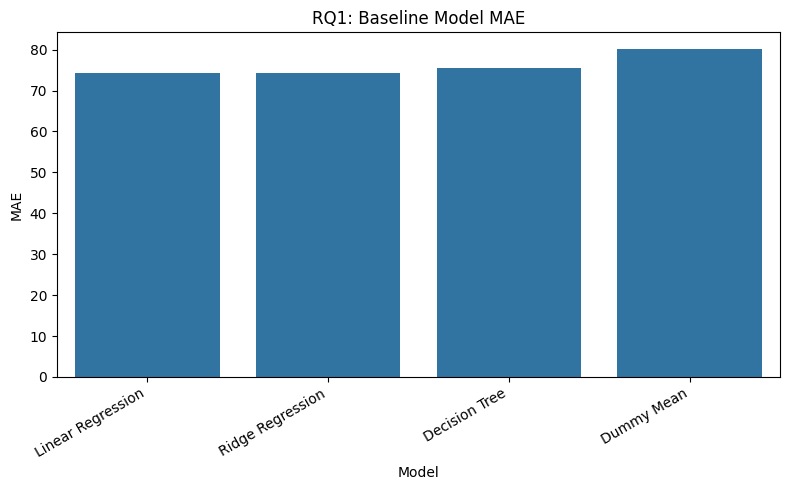

In [6]:
baseline_models = {
    'Dummy Mean': DummyRegressor(strategy='mean'),
    'Linear Regression': LinearRegression(),
    'Ridge Regression': Ridge(alpha=1.0),
    'Decision Tree': DecisionTreeRegressor(max_depth=8, random_state=RANDOM_STATE)
}

rq1_results = []
rq1_pipelines = {}
for name, estimator in baseline_models.items():
    scaling = 'standard' if name in ['Linear Regression', 'Ridge Regression'] else 'none'
    pipe, metrics = fit_evaluate_model(name, estimator, scaling=scaling)
    rq1_pipelines[name] = pipe
    rq1_results.append(metrics)

rq1_table = pd.DataFrame(rq1_results)[['Model', 'MAE', 'RMSE', 'R2']].sort_values('MAE')
display(rq1_table)
rq1_table.to_csv(TABLE_DIR / 'RQ1_baseline_performance.csv', index=False)

plt.figure(figsize=(8, 5))
sns.barplot(data=rq1_table, x='Model', y='MAE')
plt.title('RQ1: Baseline Model MAE')
plt.xticks(rotation=30, ha='right')
plt.tight_layout()
plt.savefig(FIGURE_DIR / 'RQ1_baseline_mae.pdf')
plt.show()

## RQ2 — Model Comparison

**Question:** Which supervised learning model achieves the best predictive performance for Airbnb listing price prediction?

Training: Linear Regression
Training: Ridge Regression
Training: Decision Tree
Training: Random Forest
Training: Gradient Boosting
Best model by MAE: Random Forest


,Model,MAE,RMSE,R2
3,Random Forest,73.692268,109.907752,0.117425
4,Gradient Boosting,73.871053,110.175161,0.113125
0,Linear Regression,74.246366,111.051022,0.098968
1,Ridge Regression,74.246384,111.051010,0.098968
2,Decision Tree,75.122228,111.580827,0.090350


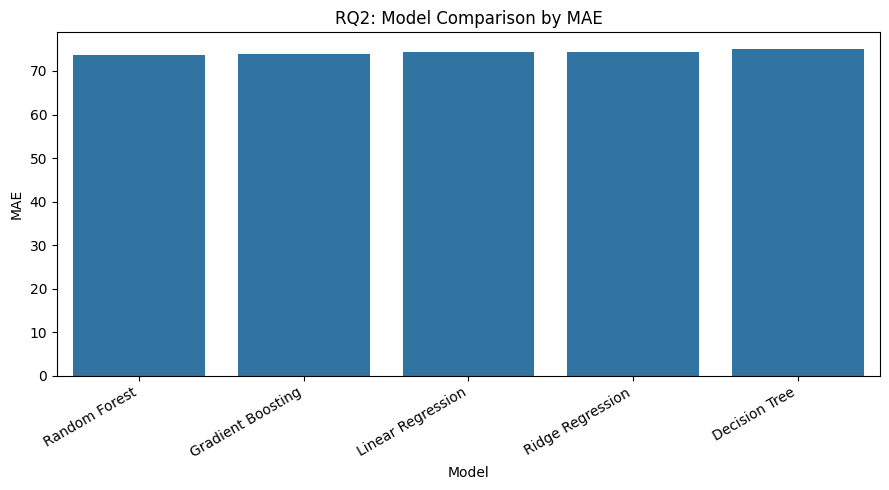

In [7]:
candidate_models = {
    'Linear Regression': LinearRegression(),
    'Ridge Regression': Ridge(alpha=1.0),
    'Decision Tree': DecisionTreeRegressor(max_depth=10, random_state=RANDOM_STATE),
    'Random Forest': RandomForestRegressor(n_estimators=150, max_depth=14, random_state=RANDOM_STATE, n_jobs=-1),
    'Gradient Boosting': GradientBoostingRegressor(random_state=RANDOM_STATE)
}

# SVR can be slow on large data. Use it only if dataset is not too large.
if SVR is not None and len(X_train) <= 15000:
    candidate_models['SVR'] = SVR(C=10, epsilon=0.2)

rq2_results = []
rq2_pipelines = {}
for name, estimator in candidate_models.items():
    scaling = 'standard' if name in ['Linear Regression', 'Ridge Regression', 'SVR'] else 'none'
    print('Training:', name)
    pipe, metrics = fit_evaluate_model(name, estimator, scaling=scaling)
    rq2_pipelines[name] = pipe
    rq2_results.append(metrics)

rq2_table = pd.DataFrame(rq2_results)[['Model', 'MAE', 'RMSE', 'R2']].sort_values('MAE')
best_model_name = rq2_table.iloc[0]['Model']
best_pipeline = rq2_pipelines[best_model_name]

print('Best model by MAE:', best_model_name)
display(rq2_table)
rq2_table.to_csv(TABLE_DIR / 'RQ2_model_comparison.csv', index=False)
joblib.dump(best_pipeline, MODEL_DIR / 'best_model_pipeline.joblib')

plt.figure(figsize=(9, 5))
sns.barplot(data=rq2_table, x='Model', y='MAE')
plt.title('RQ2: Model Comparison by MAE')
plt.xticks(rotation=30, ha='right')
plt.tight_layout()
plt.savefig(FIGURE_DIR / 'RQ2_model_comparison_mae.pdf')
plt.show()

## RQ3 — Effect of Preprocessing

**Question:** How do imputation, scaling, and outlier handling influence model performance?

,Experiment,Rows,MAE,RMSE,R2
3,"Median imputation, no scaling, 5-95% target cap",646165,55.578503,73.408314,0.109381
0,"Median imputation, no scaling, 1-99% target cap",703460,74.062697,110.209689,0.112569
1,"Median imputation, standard scaling, 1-99% tar...",703460,74.063080,110.208820,0.112583
2,"Median imputation, robust scaling, 1-99% targe...",703460,74.063652,110.209967,0.112565


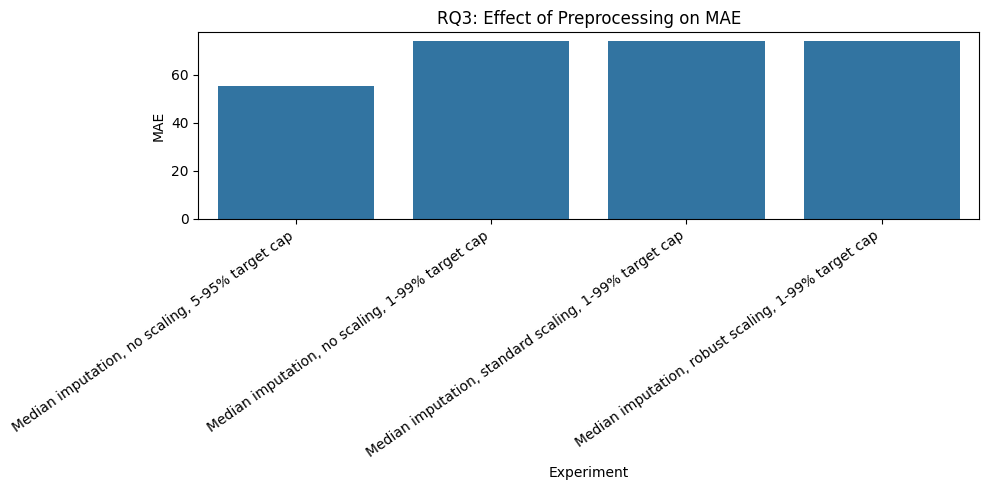

In [8]:
preprocessing_experiments = []

experiment_configs = [
    {'name': 'Median imputation, no scaling, 1-99% target cap', 'scaling': 'none', 'lower_q': 0.01, 'upper_q': 0.99},
    {'name': 'Median imputation, standard scaling, 1-99% target cap', 'scaling': 'standard', 'lower_q': 0.01, 'upper_q': 0.99},
    {'name': 'Median imputation, robust scaling, 1-99% target cap', 'scaling': 'robust', 'lower_q': 0.01, 'upper_q': 0.99},
    {'name': 'Median imputation, no scaling, 5-95% target cap', 'scaling': 'none', 'lower_q': 0.05, 'upper_q': 0.95},
]

base_estimator = RandomForestRegressor(n_estimators=120, max_depth=12, random_state=RANDOM_STATE, n_jobs=-1)

for cfg in experiment_configs:
    temp_df = cap_target_outliers(model_df, cfg['lower_q'], cfg['upper_q'])
    X_temp = temp_df.drop(columns=[TARGET_COLUMN])
    y_temp = temp_df[TARGET_COLUMN]
    if high_card_cols:
        X_temp = X_temp.drop(columns=[c for c in high_card_cols if c in X_temp.columns], errors='ignore')
    X_tr, X_te, y_tr, y_te = train_test_split(X_temp, y_temp, test_size=0.2, random_state=RANDOM_STATE)

    pipe = Pipeline([
        ('preprocess', make_preprocessor(scaling=cfg['scaling'])),
        ('model', clone(base_estimator))
    ])
    pipe.fit(X_tr, y_tr)
    preds = pipe.predict(X_te)
    metrics = evaluate_predictions(y_te, preds)
    metrics['Experiment'] = cfg['name']
    metrics['Rows'] = len(temp_df)
    preprocessing_experiments.append(metrics)

rq3_table = pd.DataFrame(preprocessing_experiments)[['Experiment', 'Rows', 'MAE', 'RMSE', 'R2']].sort_values('MAE')
display(rq3_table)
rq3_table.to_csv(TABLE_DIR / 'RQ3_preprocessing_effect.csv', index=False)

plt.figure(figsize=(10, 5))
sns.barplot(data=rq3_table, x='Experiment', y='MAE')
plt.title('RQ3: Effect of Preprocessing on MAE')
plt.xticks(rotation=35, ha='right')
plt.tight_layout()
plt.savefig(FIGURE_DIR / 'RQ3_preprocessing_effect_mae.pdf')
plt.show()

## RQ4 — Feature Importance and Interpretability

**Question:** Which listing characteristics most strongly influence Airbnb pricing?

,feature,importance
3,booking_lead_time_avg,0.278125
5,min_nights_avg,0.119345
41,country_United Kingdom,0.104943
4,length_of_stay_avg,0.096302
0,vacant_days,0.056856
2,occupancy,0.054801
1,reserved_days,0.031708
27,country_Netherlands,0.019687
36,country_Spain,0.016619
48,date_2025-08-01,0.016504


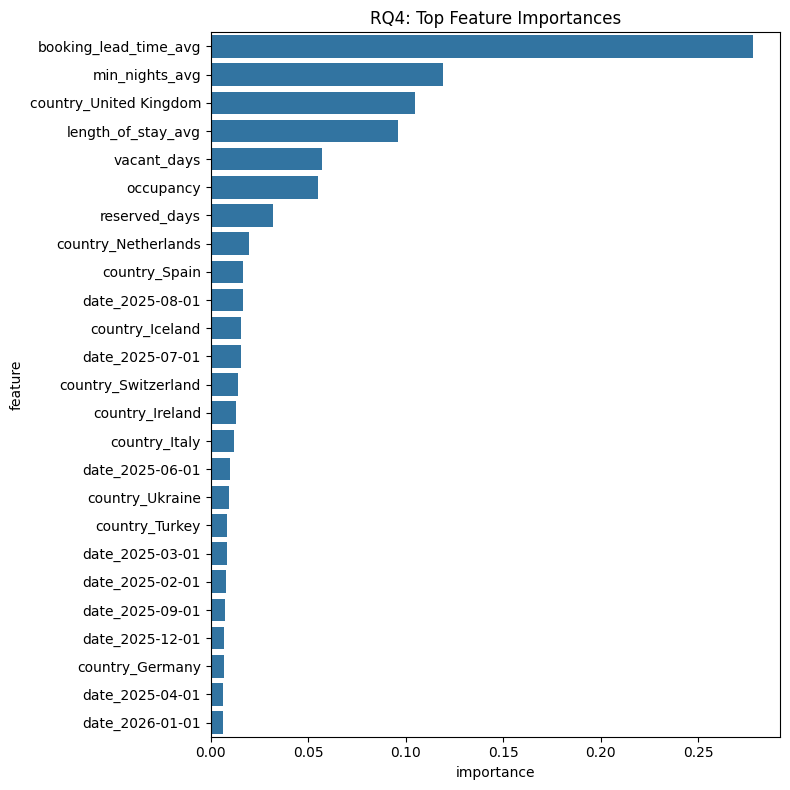

In [9]:
# Prefer tree-based feature importance if best model supports it; otherwise use permutation importance.
preprocessor = best_pipeline.named_steps['preprocess']
model = best_pipeline.named_steps['model']

def get_feature_names(preprocessor):
    names = []
    if numeric_features:
        names.extend(numeric_features)
    if categorical_features:
        try:
            cat_names = preprocessor.named_transformers_['cat'].named_steps['encoder'].get_feature_names_out(categorical_features)
            names.extend(cat_names.tolist())
        except Exception:
            pass
    return names

feature_names = get_feature_names(preprocessor)

if hasattr(model, 'feature_importances_') and len(feature_names) == len(model.feature_importances_):
    importance_df = pd.DataFrame({
        'feature': feature_names,
        'importance': model.feature_importances_
    }).sort_values('importance', ascending=False)
else:
    print('Using permutation importance. This may take a moment.')
    perm = permutation_importance(best_pipeline, X_test, y_test, n_repeats=5, random_state=RANDOM_STATE, scoring='neg_mean_absolute_error')
    importance_df = pd.DataFrame({
        'feature': X_test.columns,
        'importance': perm.importances_mean
    }).sort_values('importance', ascending=False)

top_importance = importance_df.head(25)
display(top_importance)
importance_df.to_csv(TABLE_DIR / 'RQ4_feature_importance.csv', index=False)

plt.figure(figsize=(8, 8))
sns.barplot(data=top_importance, y='feature', x='importance')
plt.title('RQ4: Top Feature Importances')
plt.tight_layout()
plt.savefig(FIGURE_DIR / 'RQ4_feature_importance.pdf')
plt.show()

## RQ5 — Sensitivity to Evaluation Metrics

**Question:** How does model ranking change when using MAE, RMSE, and R²?

,Model,MAE,RMSE,R2,Rank_MAE,Rank_RMSE,Rank_R2
3,Random Forest,73.692268,109.907752,0.117425,1,1,1
4,Gradient Boosting,73.871053,110.175161,0.113125,2,2,2
0,Linear Regression,74.246366,111.051022,0.098968,3,4,4
1,Ridge Regression,74.246384,111.051010,0.098968,4,3,3
2,Decision Tree,75.122228,111.580827,0.090350,5,5,5


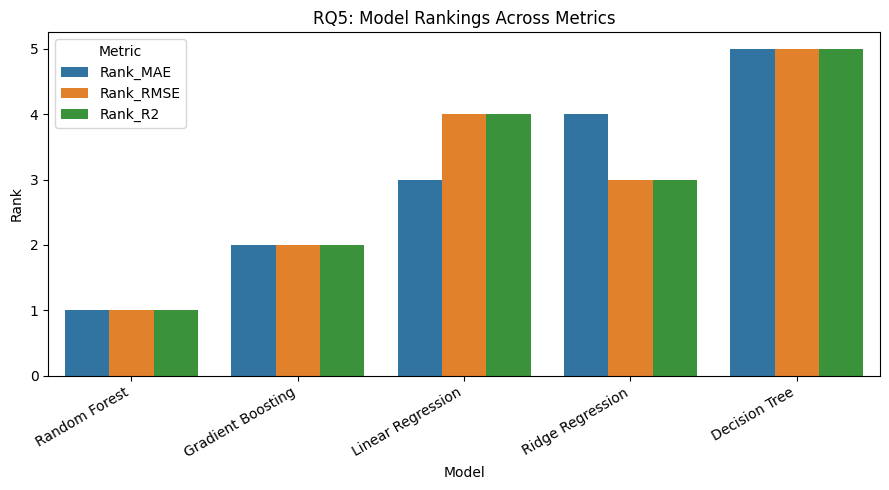

In [10]:
rq5_table = rq2_table.copy()
rq5_table['Rank_MAE'] = rq5_table['MAE'].rank(method='min', ascending=True).astype(int)
rq5_table['Rank_RMSE'] = rq5_table['RMSE'].rank(method='min', ascending=True).astype(int)
rq5_table['Rank_R2'] = rq5_table['R2'].rank(method='min', ascending=False).astype(int)
rq5_table = rq5_table.sort_values('Rank_MAE')

display(rq5_table)
rq5_table.to_csv(TABLE_DIR / 'RQ5_metric_sensitivity_rankings.csv', index=False)

rank_long = rq5_table.melt(id_vars='Model', value_vars=['Rank_MAE', 'Rank_RMSE', 'Rank_R2'], var_name='Metric', value_name='Rank')
plt.figure(figsize=(9, 5))
sns.barplot(data=rank_long, x='Model', y='Rank', hue='Metric')
plt.title('RQ5: Model Rankings Across Metrics')
plt.xticks(rotation=30, ha='right')
plt.tight_layout()
plt.savefig(FIGURE_DIR / 'RQ5_metric_rankings.pdf')
plt.show()

## RQ6 — Robustness and Generalization

**Question:** How robust is the selected model under cross-validation, noise, and missing-data perturbations?

,Metric,Mean,Std
0,MAE,73.810144,0.116020
1,RMSE,110.386767,0.355466
2,R2,0.114407,0.001882


,Scenario,MAE,RMSE,R2
0,Original test set,73.692268,109.907752,0.117425
1,5% numeric noise,74.281735,110.382757,0.109780
2,5% artificial missing values,73.932013,110.649010,0.105480


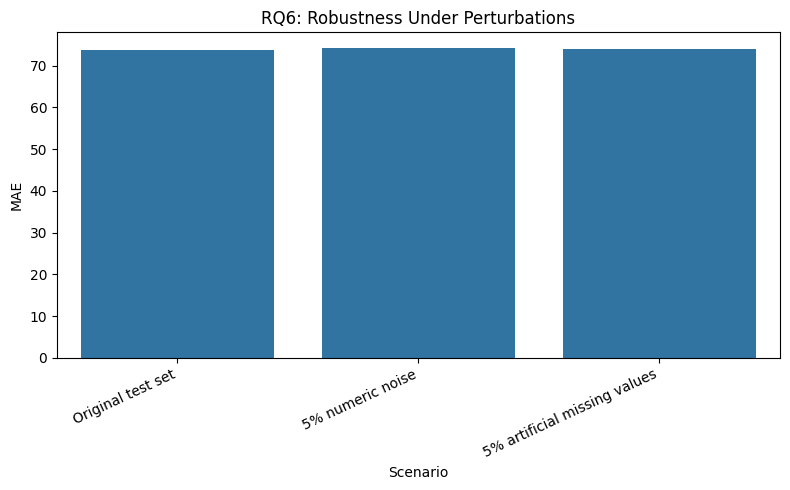

In [11]:
selected_estimator = clone(best_pipeline)
cv = KFold(n_splits=5, shuffle=True, random_state=RANDOM_STATE)
cv_scores = cross_validate(
    selected_estimator, X, y, cv=cv,
    scoring={'MAE': 'neg_mean_absolute_error', 'RMSE': 'neg_root_mean_squared_error', 'R2': 'r2'},
    n_jobs=-1
)

cv_summary = pd.DataFrame({
    'Metric': ['MAE', 'RMSE', 'R2'],
    'Mean': [-cv_scores['test_MAE'].mean(), -cv_scores['test_RMSE'].mean(), cv_scores['test_R2'].mean()],
    'Std': [cv_scores['test_MAE'].std(), cv_scores['test_RMSE'].std(), cv_scores['test_R2'].std()]
})

robustness_rows = []
# Base test performance
base_preds = best_pipeline.predict(X_test)
base_metrics = evaluate_predictions(y_test, base_preds)
base_metrics['Scenario'] = 'Original test set'
robustness_rows.append(base_metrics)

# Noise perturbation on numeric columns
X_noise = X_test.copy()
for col in numeric_features:
    if col in X_noise.columns:
        std = X_noise[col].std(skipna=True)
        if pd.notna(std) and std > 0:
            X_noise[col] = X_noise[col] + np.random.default_rng(RANDOM_STATE).normal(0, 0.05 * std, size=len(X_noise))
noise_preds = best_pipeline.predict(X_noise)
noise_metrics = evaluate_predictions(y_test, noise_preds)
noise_metrics['Scenario'] = '5% numeric noise'
robustness_rows.append(noise_metrics)

# Missing-data perturbation
X_missing = X_test.copy()
rng = np.random.default_rng(RANDOM_STATE)
for col in X_missing.columns:
    mask = rng.random(len(X_missing)) < 0.05
    X_missing.loc[mask, col] = np.nan
missing_preds = best_pipeline.predict(X_missing)
missing_metrics = evaluate_predictions(y_test, missing_preds)
missing_metrics['Scenario'] = '5% artificial missing values'
robustness_rows.append(missing_metrics)

rq6_table = pd.DataFrame(robustness_rows)[['Scenario', 'MAE', 'RMSE', 'R2']]

display(cv_summary)
display(rq6_table)
cv_summary.to_csv(TABLE_DIR / 'RQ6_cross_validation_summary.csv', index=False)
rq6_table.to_csv(TABLE_DIR / 'RQ6_robustness_perturbations.csv', index=False)

plt.figure(figsize=(8, 5))
sns.barplot(data=rq6_table, x='Scenario', y='MAE')
plt.title('RQ6: Robustness Under Perturbations')
plt.xticks(rotation=25, ha='right')
plt.tight_layout()
plt.savefig(FIGURE_DIR / 'RQ6_robustness_mae.pdf')
plt.show()

## RQ7 — Practical Usefulness and Final Recommendation

**Question:** To what extent can machine learning support data-driven pricing strategies for Airbnb hosts?

In [12]:
best_row = rq2_table.iloc[0].to_dict()
top_features = importance_df.head(10)['feature'].tolist() if 'importance_df' in globals() else []

recommendation = pd.DataFrame([
    {
        'Area': 'Predictive performance',
        'Finding': f"Best model: {best_model_name}; MAE={best_row['MAE']:.2f}, RMSE={best_row['RMSE']:.2f}, R2={best_row['R2']:.3f}",
        'Practical implication': 'The model can support approximate pricing, but should not replace host judgement.'
    },
    {
        'Area': 'Interpretability',
        'Finding': 'Top drivers include: ' + ', '.join(top_features[:5]),
        'Practical implication': 'Hosts and analysts can use important factors to understand pricing drivers.'
    },
    {
        'Area': 'Deployment constraints',
        'Finding': 'Performance depends on clean input data, city coverage, and stable market conditions.',
        'Practical implication': 'A deployed model should be monitored and retrained when market conditions change.'
    },
    {
        'Area': 'Final recommendation',
        'Finding': 'Use ML as a decision-support tool for suggested price ranges, not as a fully automated pricing authority.',
        'Practical implication': 'Combine predictions with local market knowledge, seasonality, and host strategy.'
    }
])

display(recommendation)
recommendation.to_csv(TABLE_DIR / 'RQ7_final_recommendation.csv', index=False)

with open(OUTPUT_DIR / 'RQ7_final_recommendation.txt', 'w') as f:
    for _, row in recommendation.iterrows():
        f.write(f"{row['Area']}\n{row['Finding']}\n{row['Practical implication']}\n\n")

print('All RQ outputs saved to:', OUTPUT_DIR.resolve())
print('Figures saved to:', FIGURE_DIR.resolve())
print('Tables saved to:', TABLE_DIR.resolve())

,Area,Finding,Practical implication
0,Predictive performance,"Best model: Random Forest; MAE=73.69, RMSE=109...","The model can support approximate pricing, but..."
1,Interpretability,"Top drivers include: booking_lead_time_avg, mi...",Hosts and analysts can use important factors t...
2,Deployment constraints,"Performance depends on clean input data, city ...",A deployed model should be monitored and retra...
3,Final recommendation,Use ML as a decision-support tool for suggeste...,Combine predictions with local market knowledg...


All RQ outputs saved to: /Users/oleg/ML_homework/outputs
Figures saved to: /Users/oleg/ML_homework/outputs/figures
Tables saved to: /Users/oleg/ML_homework/outputs/tables


## 8. Output checklist

In [13]:
print('Tables:')
for p in sorted(TABLE_DIR.glob('*.csv')):
    print('-', p.name)

print('\nFigures:')
for p in sorted(FIGURE_DIR.glob('*.pdf')):
    print('-', p.name)

print('\nModels:')
for p in sorted(MODEL_DIR.glob('*')):
    print('-', p.name)

Tables:
- RQ1_baseline_performance.csv
- RQ2_model_comparison.csv
- RQ3_preprocessing_effect.csv
- RQ4_feature_importance.csv
- RQ5_metric_sensitivity_rankings.csv
- RQ6_cross_validation_summary.csv
- RQ6_robustness_perturbations.csv
- RQ7_final_recommendation.csv
- clean_model_dataframe_preview.csv
- data_missingness_top30.csv
- dropped_leakage_id_text_columns.csv
- raw_columns_overview.csv

Figures:
- RQ1_baseline_mae.pdf
- RQ2_model_comparison_mae.pdf
- RQ3_preprocessing_effect_mae.pdf
- RQ4_feature_importance.pdf
- RQ5_metric_rankings.pdf
- RQ6_robustness_mae.pdf
- target_distribution_raw.pdf

Models:
- best_model_pipeline.joblib


In [16]:
print(f"Dataset 1 (uncleaned): {raw_tables[0].shape[0]} rows × {raw_tables[0].shape[1]} columns")
print(f"Dataset 2 (uncleaned): {raw_tables[1].shape[0]} rows × {raw_tables[1].shape[1]} columns")

Dataset 1 (uncleaned): 95898 rows × 63 columns
Dataset 2 (uncleaned): 1115174 rows × 19 columns
